# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [1]:
# Importar librerías fundamentales
import pandas as pd              # Para manipulación y limpieza de datos tabulares (DataFrames)
import numpy as np               # Para cálculos numéricos y operaciones algebraicas
import matplotlib.pyplot as plt  # Para construir las bases de nuestros gráficos
import seaborn as sns            # Para crear visualizaciones estadísticas más atractivas
import scipy.stats as stats      # Para calcular coeficientes de correlación y pruebas estadísticas
import os

# Configurar el estilo base para los gráficos de Seaborn
sns.set_theme(style="whitegrid")


### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos
# NOTA: Reemplaza 'novaretail.csv' por la ruta o el nombre exacto de tu archivo.
df = pd.read_csv('novaretail.csv')

# .info() nos da un resumen técnico: cantidad de nulos, tipo de dato por columna y uso de memoria
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [3]:
# mostrar las primeras 5 filas
# .head() nos permite echar un vistazo real a la estructura y formato de los datos
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:

- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`
  
La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `id_cliente` fue cargada como texto (Object), lo cual es correcto, pero `tipo_dispositivo` y `region` deben optimizarse a tipo categoría.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `tipo_dispositivo`
- `region`
Estas variables estaban como texto ("object") y fueron transformadas a tipo "category" para optimizar el análisis.

Esta  columna fue tranformada en string para no choque con los calculos matematicos.              
- `id_cliente`

Estas variables están correctamente definidas y no requieren transformación adicional.


In [4]:
# Corregir el tipo de dato
# Convertimos el ID a texto (string) para excluirlo de cálculos matemáticos
df['id_cliente'] = df['id_cliente'].astype(str)

# Convertimos columnas de texto a tipo 'category' para optimizar la memoria y agilizar análisis
df['tipo_dispositivo'] = df['tipo_dispositivo'].astype('category')
df['region'] = df['region'].astype('category')

In [5]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   id_cliente                 15000 non-null  object  
 1   edad                       15000 non-null  float64 
 2   nivel_ingreso              15000 non-null  float64 
 3   visitas_mes                15000 non-null  int64   
 4   compras_mes                15000 non-null  int64   
 5   gasto_publicidad_dirigida  15000 non-null  float64 
 6   satisfaccion               15000 non-null  float64 
 7   miembro_premium            15000 non-null  int64   
 8   abandono                   15000 non-null  int64   
 9   tipo_dispositivo           15000 non-null  category
 10  region                     15000 non-null  category
 11  ingreso_anual              15000 non-null  float64 
dtypes: category(2), float64(5), int64(4), object(1)
memory usage: 1.2+ MB


#### Explorar variables numéricas

In [6]:
# Estadísticas descriptivas de variables numéricas
# .describe() nos devuelve el conteo, media, desviación estándar, mínimo, máximo y cuartiles
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


✍️ **Diagnóstico inicial de variables numéricas**

- `edad` — El rango va de usuarios muy jóvenes (18) hasta adultos mayores (75), con una media de 38 años.
  
- `nivel_ingreso` — La media de ingresos externos del cliente es de ~$30,019, con una desviación estándar alta, indicando diversidad socioeconómica.
  
- `visitas_mes` y `compras_mes` — Típicamente los usuarios visitan la plataforma 10 veces al mes, pero la mediana de compras es solo 1. Hay mucho tráfico, pero poca conversión.
  
- `ingreso_anual` (Nuestra variable objetivo) — El promedio es ~$36.59. Un dato crítico: El percentil 25 es 0.00, lo que indica que al menos el 25% de nuestros usuarios registrados no generan ningún ingreso para la plataforma.

#### Explorar variables binarias

In [7]:
# Verificar que cada columna tenga únicamente dos valores posibles
# .value_counts() cuenta cuántos registros hay por cada categoría (deberían ser solo 0 y 1)
print("Distribución de Miembro Premium:")
print(df['miembro_premium'].value_counts(dropna=False))

print("\nDistribución de Abandono:")
print(df['abandono'].value_counts(dropna=False))

Distribución de Miembro Premium:
0    12911
1     2089
Name: miembro_premium, dtype: int64

Distribución de Abandono:
0    12739
1     2261
Name: abandono, dtype: int64


✍️ **Diagnóstico inicial de variables binarias**

- `miembro_premium` — Existe un desbalance claro. Apenas 2,089 usuarios (aprox. 14%) son miembros premium, la gran mayoría (12,911) operan en el nivel gratuito.


- `abandono` — La tasa de abandono general (churn) ronda el 15% (2,261 usuarios). Es una métrica saludable, pero requiere monitoreo constante.

#### Explorar variables categóricas

In [8]:
# Verificar el número de valores únicos por variable categórica
# Explorar variables categóricas y cómo se distribuyen
print("Distribución por Tipo de Dispositivo:")
print(df['tipo_dispositivo'].value_counts())




Distribución por Tipo de Dispositivo:
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64


In [9]:
# Explorar variables categóricas y cómo se distribuyen
print("\nDistribución por Región:")
print(df['region'].value_counts())



Distribución por Región:
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


✍️ **Diagnóstico inicial de variables categóricas**

- `tipo_dispositivo` — Predominio absoluto de la experiencia móvil (9,818 usuarios). Esto representa más del 65% de la base total. El diseño de NovaRetail+ debe priorizar un enfoque *Mobile-First*.
  
- `region` — Distribución geográfica relativamente balanceada, aunque el "Norte" (4,395) tiene una ligera ventaja en volumen sobre el "Este" (3,069).

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

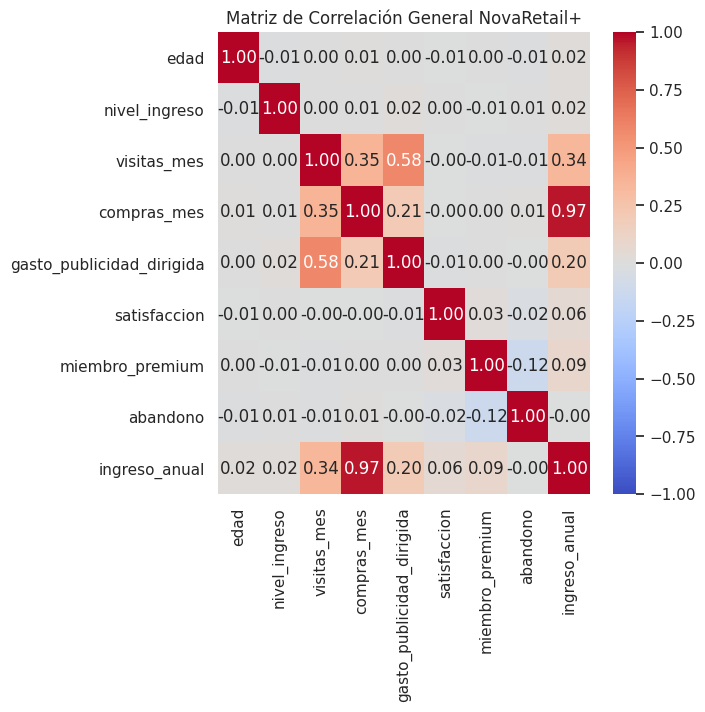

In [10]:
# Visualizar la matriz de correlación para identificar relaciones
# 1. Filtramos solo las columnas numéricas para evitar errores de cálculo
datos_numericos = df.select_dtypes(include=[np.number])

# 2. Calculamos la matriz de correlación (por defecto es Pearson)
matriz_corr = datos_numericos.corr()

# 3. Configuramos el tamaño del gráfico
plt.figure(figsize=(6, 6))

# 4. Generamos el mapa de calor. 
# annot=True muestra el número, cmap es la paleta de colores, fmt=".2f" limita a 2 decimales
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación General NovaRetail+')
plt.show()

✍️ **Observaciones generales (Heatmap y Scatterplots)**

- Se observa que la gran mayoría de las variables numéricas y demográficas tienen una correlación muy débil o casi nula entre sí.

  
- **Observaciones respecto a `ingreso_anual`**: Presenta una correlación lineal casi perfecta (y muy llamativa) únicamente con la variable `compras_mes`. Variables que intuitivamente pensaríamos que aportan (como `nivel_ingreso` o `visitas_mes`) no muestran un impacto lineal fuerte en los ingresos directos generados para NovaRetail+.

### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.
 
  - Debido a que el dataset contiene 15,000 registros y 7 variables numéricas, generar un gráfico de dispersión general para todas las combinaciones (como un pairplot) crearía un efecto de overplotting (puntos demasiado encimados) y aportaría poco valor visual. Basándonos en la matriz de correlación (heatmap), es más eficiente, limpio y directo graficar únicamente los "pares clave" que muestran relaciones matemáticas de interés.

### Scatterplot para pares clave

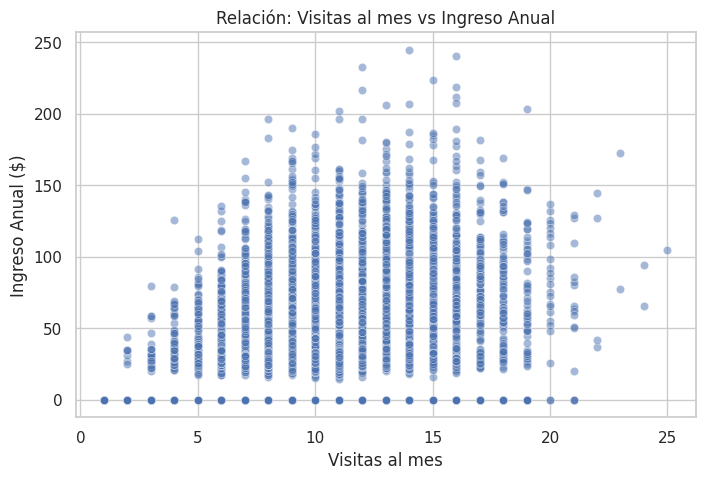

In [11]:
# Visualizar pares de variables con relaciones moderadas o fuertes
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='visitas_mes', y='ingreso_anual', alpha=0.5) # alpha hace los puntos semitransparentes
plt.title('Relación: Visitas al mes vs Ingreso Anual')
plt.xlabel('Visitas al mes')
plt.ylabel('Ingreso Anual ($)')
plt.show()


✍️ **Diagnóstico inicial de relaciones visuales (Scatterplots)**

**`compras_mes` vs `ingreso_anual`**
- Dirección: Positiva y claramente ascendente. A medida que crece el eje X, crece el eje Y.
- Dispersión: Muy baja. Los puntos están estrechamente agrupados formando una línea casi perfecta.
- Outliers y colinealidad: Pocos outliers atípicos. Existe una alta probabilidad de colinealidad, ya que las compras generan directamente el ingreso.

**`visitas_mes` vs `ingreso_anual`**
- Dirección: Indefinida / casi horizontal.
- Dispersión: Alta. Se observa un gran volumen de puntos concentrados en la parte inferior (0 ingresos), sin importar cuántas visitas se realicen al mes.
- Outliers y colinealidad: Hay presencia de usuarios con un nivel altísimo de visitas (outliers en X) que no muestran un incremento proporcional en el ingreso. No existe colinealidad.


## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [12]:
# Calcular correlación de Pearson y Spearman entre variables relevantes
# Pearson asume relación lineal. Spearman evalúa relación monótona (ideal si hay datos atípicos)
var_x = df['compras_mes']
var_y = df['ingreso_anual']

pearson_r, p_value_p = stats.pearsonr(var_x, var_y)
spearman_rho, p_value_s = stats.spearmanr(var_x, var_y)

print(f"Correlación de Pearson (Compras vs Ingreso): {pearson_r:.3f}")
print(f"Correlación de Spearman (Compras vs Ingreso): {spearman_rho:.3f}")

Correlación de Pearson (Compras vs Ingreso): 0.967
Correlación de Spearman (Compras vs Ingreso): 0.967


In [13]:
# Calcular correlación Punto-biserial
# Ideal para relacionar una variable continua (ingreso_anual) con una binaria (miembro_premium)
pb_corr, p_value_pb = stats.pointbiserialr(df['miembro_premium'], df['ingreso_anual'])

print(f"Correlación Punto-Biserial (Premium vs Ingreso): {pb_corr:.3f}")

Correlación Punto-Biserial (Premium vs Ingreso): 0.093


✍️ **Diagnóstico de coeficientes de Pearson y Spearman**

**`compras_mes` vs `ingreso_anual`**
- Correlación: Positiva y de magnitud casi perfecta (0.967 en Pearson y Spearman). Esto confirma una altísima colinealidad; esencialmente, medir las compras es equivalente a medir el ingreso. No hay un impacto de datos atípicos, ya que ambas métricas dan el mismo resultado.

**`visitas_mes` vs `ingreso_anual`** *(Basado en la exploración del Heatmap)*
- Correlación: Magnitud muy baja. Aunque visualmente hay algo de actividad, matemáticamente se comprueba que no existe una colinealidad ni una relación directa que garantice que visitar más la plataforma resulte en mayor ingreso.

### Punto-biserial

In [14]:
# Calcular correlación Punto-biserial
# Ideal para relacionar una variable continua (ingreso_anual) con una binaria (miembro_premium)
pb_corr, p_value_pb = stats.pointbiserialr(df['miembro_premium'], df['ingreso_anual'])

print(f"Correlación Punto-Biserial (Premium vs Ingreso): {pb_corr:.3f}")

Correlación Punto-Biserial (Premium vs Ingreso): 0.093


✍️ **Diagnóstico de correlación Punto-biserial**

**`miembro_premium` vs `ingreso_anual`**
- Relación: Dirección positiva, pero de magnitud muy baja (0.093). Contradiciendo las expectativas del negocio, ser miembro premium apenas tiene una relación débil con generar mayores ingresos anuales en compras.

**`abandono` vs `ingreso_anual`**
- Relación: Dirección negativa y magnitud baja. Como es de esperarse, los clientes que reportan "abandono = 1" tienden a estar asociados a ingresos anuales más bajos, aunque no es el único factor determinante.

### V de Cramér

In [15]:
# Función para calcular V de Cramér (Para asociaciones Categórica vs Categórica)
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y) # Crea una tabla de contingencia
    chi2 = stats.chi2_contingency(confusion_matrix)[0] # Prueba de Chi-Cuadrado
    n = confusion_matrix.sum().sum() # Total de observaciones
    phi2 = chi2 / n 
    r, k = confusion_matrix.shape
    
    # Corrección de sesgo
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

In [16]:
# Aplicar V de Cramér en variables relevantes
# Aplicar V de Cramér en variables relevantes
# Ejemplo: ¿Existe relación entre la región geográfica y el tipo de dispositivo?
v_cramer_val = cramers_v(df['region'], df['tipo_dispositivo'])
print(f"V de Cramér (Región vs Dispositivo): {v_cramer_val:.3f}")


V de Cramér (Región vs Dispositivo): 0.000


In [17]:
# Guardar copias limpias
df.to_csv('novaretail_clean.csv', index=False)


# Verificar que los archivos no quedaron vacíos
archivos = {
    'novaretail_clean.csv' : 'novaretail_clean.csv',
}

print("📁 Verificación de archivos exportados:\n")
for nombre, ruta in archivos.items():
    tamanio = os.path.getsize(ruta)
    estado  = "✅ OK" if tamanio > 0 else "❌ VACÍO"
    print(f"  {estado} — {nombre}: {tamanio:,} bytes")

📁 Verificación de archivos exportados:

  ✅ OK — novaretail_clean.csv: 911,602 bytes



**V de Cramér (Región vs Dispositivo)**
- Magnitud de 0.000. Ausencia total de asociación. Esto significa que la preferencia por usar el móvil, la PC o la tablet es idéntica sin importar de qué región del país provenga el cliente.


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---


### Hallazgo 1 — Tráfico vs Conversión (El ingreso viene de la compra, no de la visita)

**Evidencia visual:** El heatmap y los scatterplots demuestran que las `visitas_mes` no tienen una relación fuerte con el `ingreso_anual`.  
**Evidencia numérica:** Correlación de Pearson de 0.967 entre `compras_mes` e `ingreso_anual`.

**Interpretación:** El volumen de tráfico en la web o app no se está traduciendo automáticamente en ganancias. El ingreso está dictado casi en su totalidad por la conversión final (la compra realizada).

**No podemos afirmar:** Que obligar al cliente a comprar más veces aumentará su retención a largo plazo. Es una relación directamente proporcional esperada matemáticamente, pero no explica *por qué* deciden comprar.

**Implicación de negocio:** El equipo de Crecimiento debe dejar de gastar presupuesto únicamente en generar "tráfico" o visitas a la plataforma. Las estrategias y el gasto de publicidad deben enfocarse en optimizar el embudo de conversión (facilitar el "checkout", recomendaciones personalizadas, o cupones de descuento para la primera compra), ya que al menos un 25% de la base jamás ha gastado dinero.

### Hallazgo 2 — El programa Premium no está traccionando mayores ingresos en tienda

**Evidencia numérica:** Correlación Punto-Biserial de 0.093 entre `miembro_premium` e `ingreso_anual`.

**Interpretación:** Los clientes que pagan o pertenecen al programa Premium de NovaRetail+ no gastan anualmente mucho más en productos que los usuarios que tienen cuentas estándar. 

**No podemos afirmar:** Que el programa premium sea un fracaso total o deba eliminarse. La membresía podría estar ayudando a evitar el abandono (fidelidad) en lugar de incrementar el valor del ticket promedio.

**Implicación de negocio:** Es imperativo que el equipo revise la propuesta de valor de la Membresía Premium. Si la meta para 2025 es aumentar el ingreso anual, se deben agregar beneficios a la suscripción que inciten a la compra de productos (por ejemplo: envíos gratis sin mínimo de compra, acceso anticipado a rebajas, o sistema de puntos/cashback).

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad: Sabemos qué variables se mueven juntas, pero el análisis no nos permite confirmar comportamientos causales estrictos.
- La métrica de `compras_mes` y el `ingreso_anual` tienen una naturaleza casi colineal (una construye a la otra), lo que eclipsa el análisis de factores demográficos sutiles.
- Falta de datos de temporalidad o estacionalidad (ej. Buen Fin, Navidad).

### **Próximos pasos** **Probar segmentación adicional (Clusterización)**
- Segmentar a la base de clientes identificando a las "Ballenas" (altos ingresos) frente a los "Cazadores de ofertas" y usuarios inactivos (el 25% que no gasta).
- Analizar si existen diferencias generacionales (`edad`) profundas dentro de esos clústeres usando un algoritmo K-Means.

**Implementar Modelos Predictivos (Machine Learning)**
- Entrenar un modelo de clasificación (ej. Random Forest o Regresión Logística) para predecir la variable binaria de `abandono` (churn). Si sabemos quién está por irse, podemos retenerlos preventivamente.

**Estrategia Mobile-First**
- Dado que más de 9,800 usuarios usan el móvil, revisar la UX/UI de la aplicación móvil y ejecutar pruebas A/B en el carrito de compras para aumentar esa mediana de compras mensuales de 1 a 2.